Diamond price prediction using ML


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

import warnings
warnings.filterwarnings("ignore")

part 1 DATA UNDERSTANDING


Loading the dataset and first five records

In [3]:
import pandas as pd

df = pd.read_csv("diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


last five records

In [4]:
df.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


shape of dataset information

dataset information


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


data types

In [6]:
df.dtypes

carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Missing values


In [7]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Duplicate records


In [8]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 146


descriptive statstics

In [9]:
df.describe(include='all')

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


dataset columns

In [10]:
print(df.columns)

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')


dataset summary

In [11]:
print("Total Rows :", df.shape[0])
print("Total Columns :", df.shape[1])
print("Missing Values :", df.isnull().sum().sum())
print("Duplicate Records :", df.duplicated().sum())

Total Rows : 53940
Total Columns : 10
Missing Values : 0
Duplicate Records : 146


PART 2
EXPLORATORY DATA ANALYSIS

Distribution of price

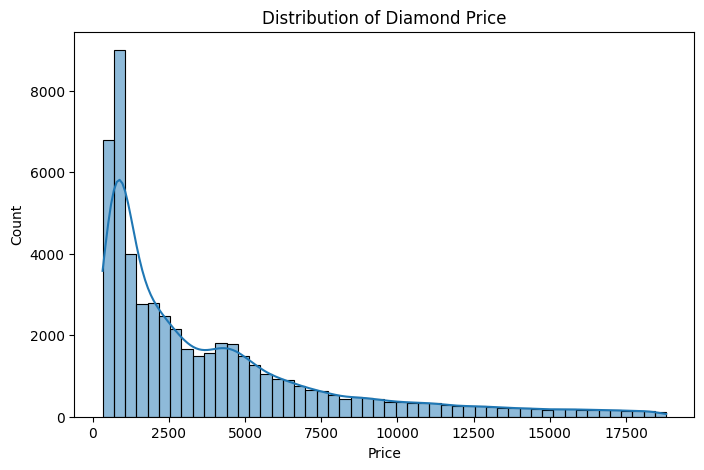

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of Diamond Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

Distribution of Carat

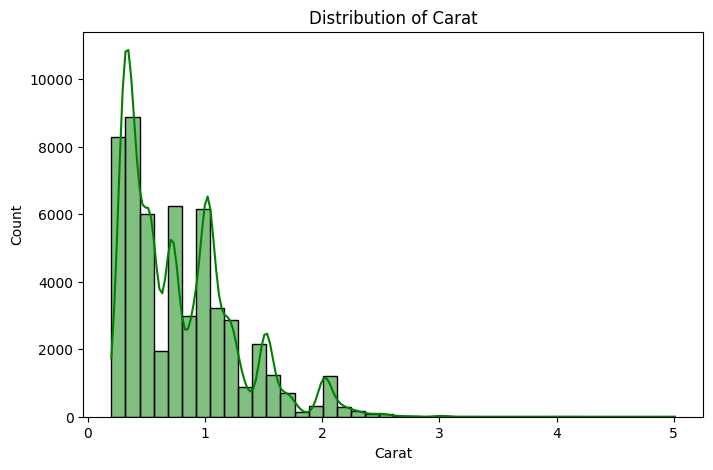

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['carat'], bins=40, kde=True, color='green')
plt.title("Distribution of Carat")
plt.xlabel("Carat")
plt.ylabel("Count")
plt.show()

Carat vs Price


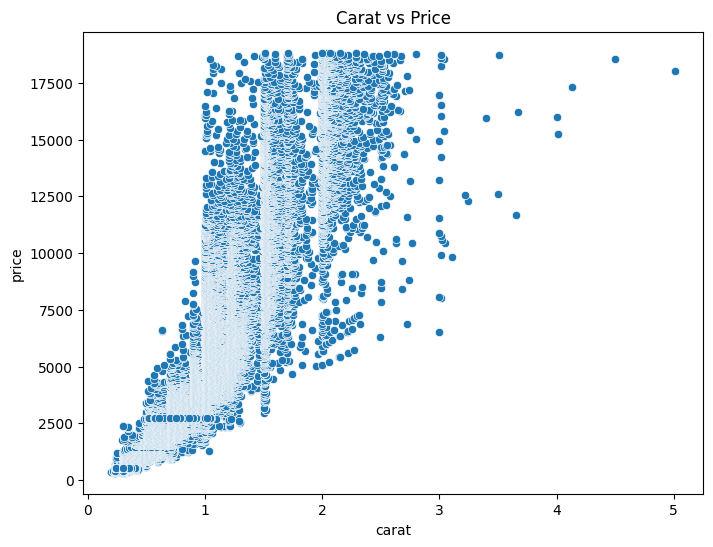

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='carat', y='price', data=df)
plt.title("Carat vs Price")
plt.show()

Average Price by Cut

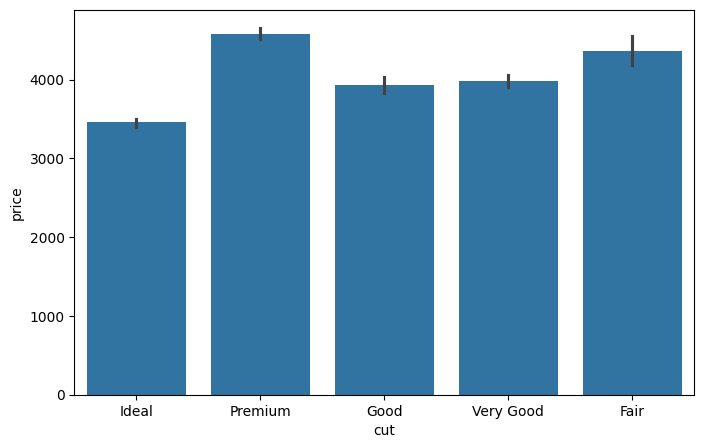

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x='cut',y='price',data=df)
plt.show()


Average Price by Color

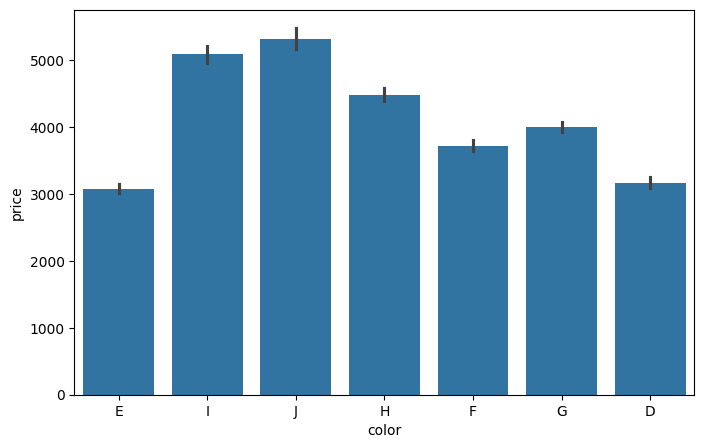

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x='color',y='price',data=df)
plt.show()

Average Price by Clarity

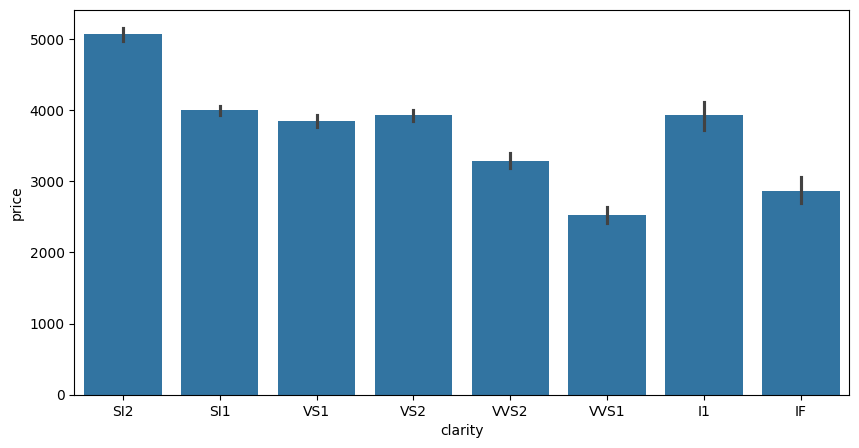

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(x='clarity',y='price',data=df)
plt.show()

Correlation Heatmap

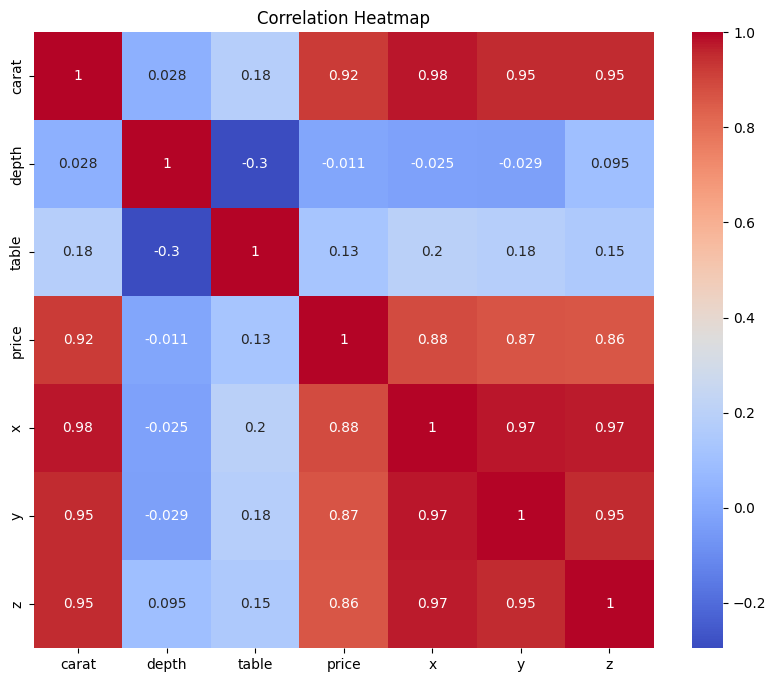

In [18]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Part 3 Data Preprocessing
Missing Values

In [19]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

No missing values.)
Remove Duplicates

In [20]:
# Check duplicate records

print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 146


detect outliers

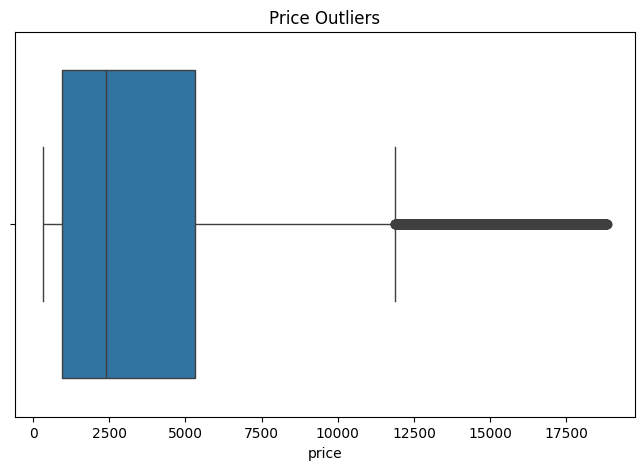

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.title("Price Outliers")

plt.show()

Outlier Removal


In [22]:
Q1 = df['price'].quantile(0.25)

Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

print(df.shape)

(50400, 10)


Encode Categorical Variables

In [23]:
cut_encoder = LabelEncoder()

color_encoder = LabelEncoder()

clarity_encoder = LabelEncoder()

df['cut'] = cut_encoder.fit_transform(df['cut'])

df['color'] = color_encoder.fit_transform(df['color'])

df['clarity'] = clarity_encoder.fit_transform(df['clarity'])

In [24]:
X = df.drop('price', axis=1)

y = df['price']

print(X.shape)

print(y.shape)

(50400, 9)
(50400,)


Feature Scaling

In [25]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

Train Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data : (40320, 9)
Testing Data : (10080, 9)


verify


In [27]:
print(type(X_train))

print(type(y_train))

print(type(X_test))

print(type(y_test))

<class 'numpy.ndarray'>
<class 'pandas.Series'>
<class 'numpy.ndarray'>
<class 'pandas.Series'>


Part 4 Model Building
Linear Regression

In [28]:
lr=LinearRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

Ridge Regression

In [29]:
ridge=Ridge(alpha=1)

ridge.fit(X_train,y_train)

pred_ridge=ridge.predict(X_test)

Lasso Regression

In [30]:
lasso=Lasso(alpha=0.1)

lasso.fit(X_train,y_train)

pred_lasso=lasso.predict(X_test)

Elastic Net

In [31]:
elastic=ElasticNet(alpha=0.1,l1_ratio=0.5)

elastic.fit(X_train,y_train)

pred_elastic=elastic.predict(X_test)

Part 5 Evaluation

In [32]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    n = len(y_true)

    p = X_test.shape[1]

    adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

    return mae, mse, rmse, r2, adjusted_r2

Linear Regression

In [33]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


Ridge

In [34]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

print("Ridge Regression Model Trained Successfully")

Ridge Regression Model Trained Successfully


Lasso

In [35]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

print("Lasso Regression Model Trained Successfully")

Lasso Regression Model Trained Successfully



Elastic Net

In [36]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_test)

print("Elastic Net Model Trained Successfully")

Elastic Net Model Trained Successfully


Comparison Table

In [37]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    n = len(y_true)

    p = X_test.shape[1]

    adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

    return mae, mse, rmse, r2, adj_r2

In [38]:
mae_lr, mse_lr, rmse_lr, r2_lr, adj_lr = evaluate(y_test, pred_lr)

In [39]:
mae_ridge, mse_ridge, rmse_ridge, r2_ridge, adj_ridge = evaluate(y_test, pred_ridge)

In [40]:
mae_lasso, mse_lasso, rmse_lasso, r2_lasso, adj_lasso = evaluate(y_test, pred_lasso)

In [41]:
mae_elastic, mse_elastic, rmse_elastic, r2_elastic, adj_elastic = evaluate(y_test, pred_elastic)

In [42]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],

    "MAE":[
        mae_lr,
        mae_ridge,
        mae_lasso,
        mae_elastic
    ],

    "MSE":[
        mse_lr,
        mse_ridge,
        mse_lasso,
        mse_elastic
    ],

    "RMSE":[
        rmse_lr,
        rmse_ridge,
        rmse_lasso,
        rmse_elastic
    ],

    "R2 Score":[
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_elastic
    ],

    "Adjusted R2":[
        adj_lr,
        adj_ridge,
        adj_lasso,
        adj_elastic
    ]

})

print(results)

               Model         MAE           MSE         RMSE  R2 Score  \
0  Linear Regression  650.683969  9.350779e+05   966.994253  0.873215   
1   Ridge Regression  650.756918  9.350937e+05   967.002411  0.873213   
2   Lasso Regression  650.815602  9.351606e+05   967.037013  0.873204   
3        Elastic Net  720.583186  1.012178e+06  1006.070461  0.862762   

   Adjusted R2  
0     0.873102  
1     0.873100  
2     0.873091  
3     0.862639  


Actual vs predicted peices(lr)

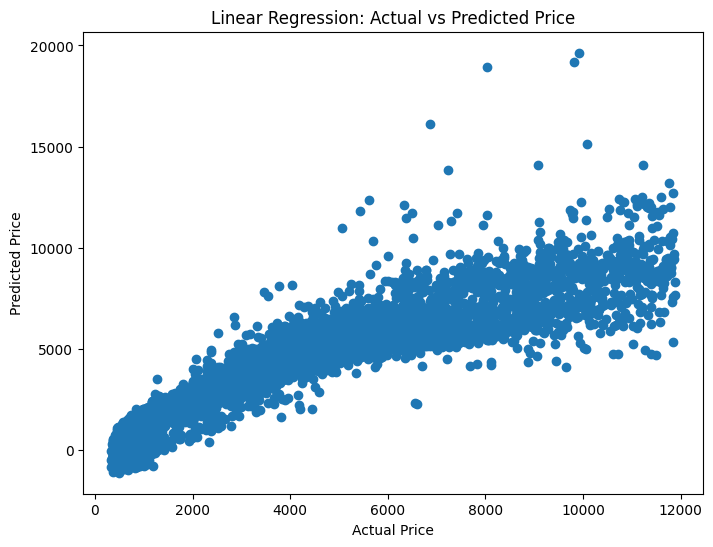

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_lr)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Price")

plt.show()

prediction Error(Residual plot)

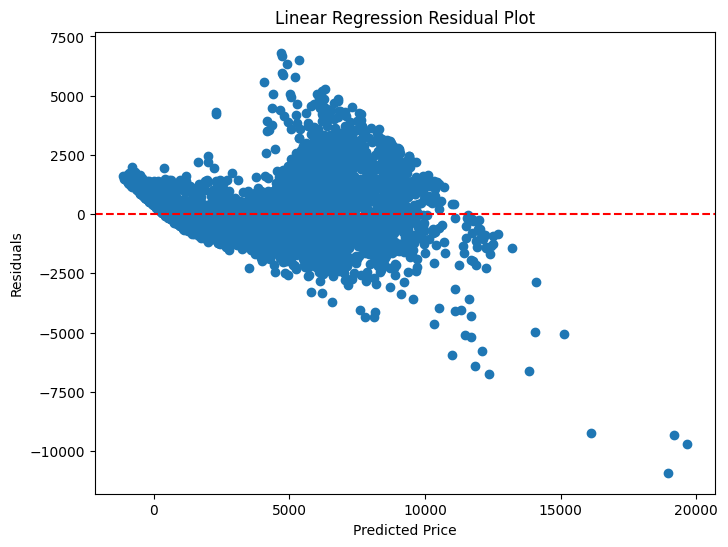

In [45]:
residuals = y_test - pred_lr

plt.figure(figsize=(8,6))

plt.scatter(pred_lr, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")

plt.show()

distribution of residual

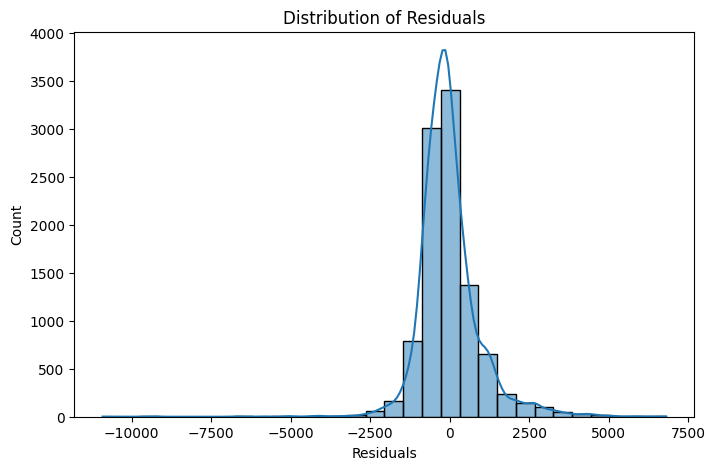

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residuals")

plt.show()

line plot of actual vs predicted

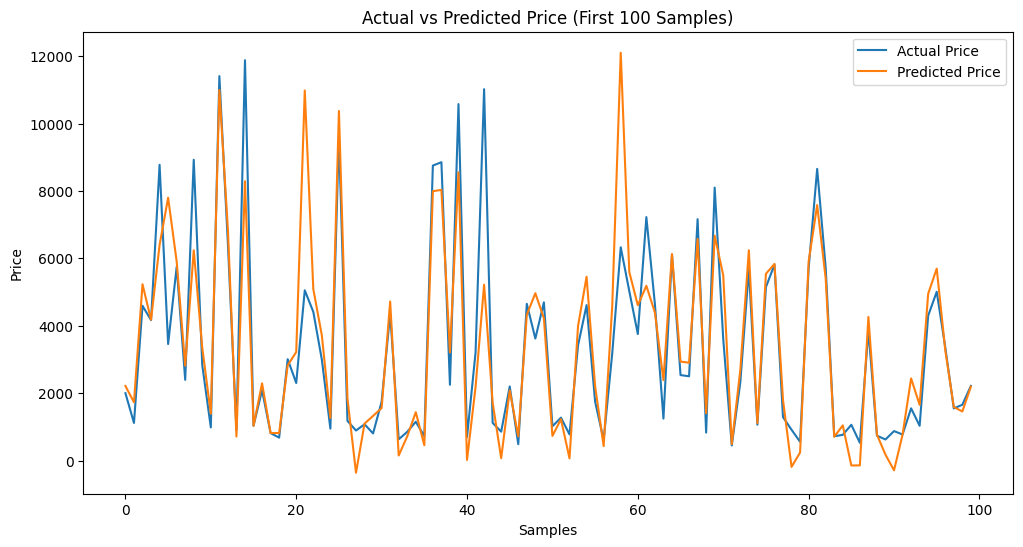

In [47]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual Price")
plt.plot(pred_lr[:100], label="Predicted Price")

plt.title("Actual vs Predicted Price (First 100 Samples)")
plt.xlabel("Samples")
plt.ylabel("Price")

plt.legend()

plt.show()

Ridge regression

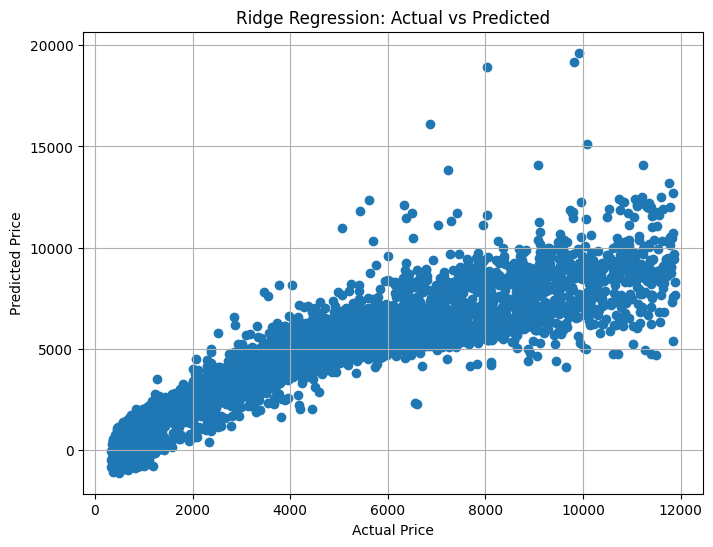

In [49]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_ridge)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

Residual plot

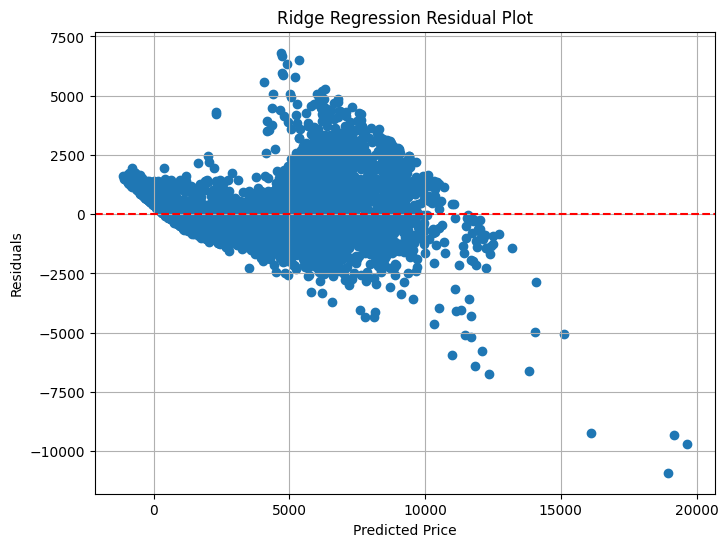

In [50]:
plt.figure(figsize=(8,6))
plt.scatter(pred_ridge, y_test - pred_ridge)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Ridge Regression Residual Plot")
plt.grid(True)
plt.show()

Lasso regression
actual vs predicted

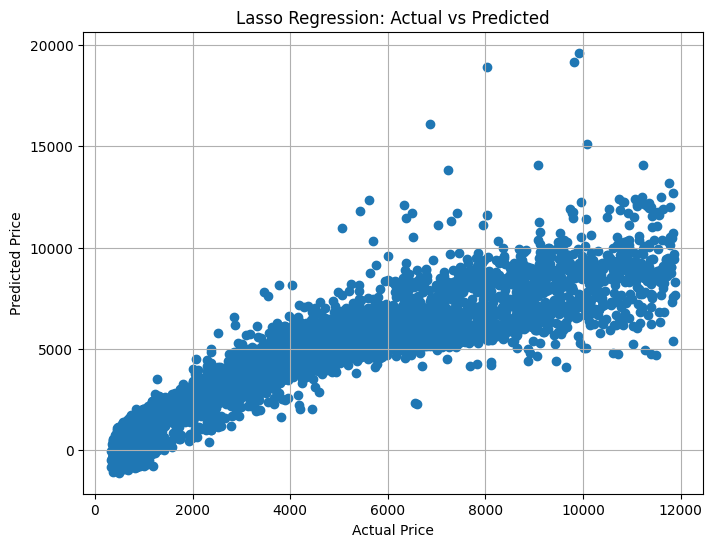

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_lasso)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

residual plot

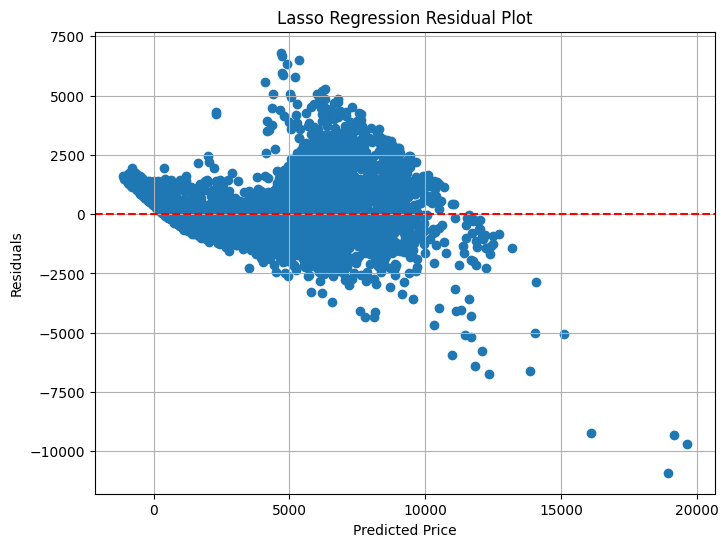

In [52]:
plt.figure(figsize=(8,6))
plt.scatter(pred_lasso, y_test - pred_lasso)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Lasso Regression Residual Plot")
plt.grid(True)
plt.show()

Elastic net regression

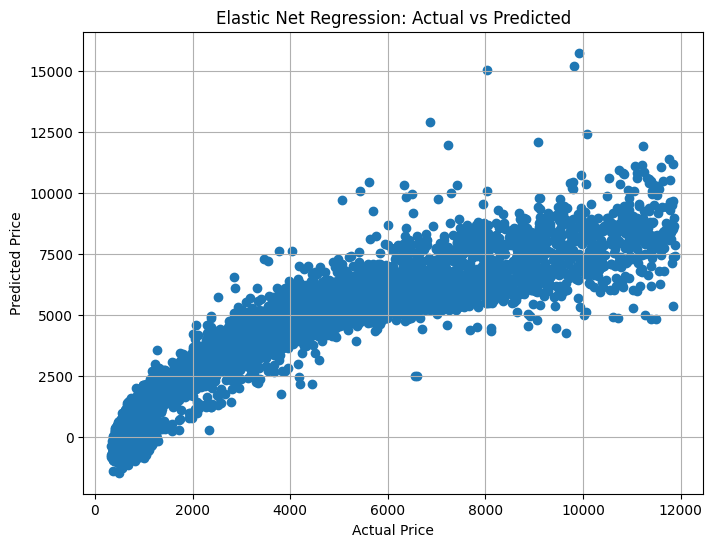

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_elastic)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Elastic Net Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

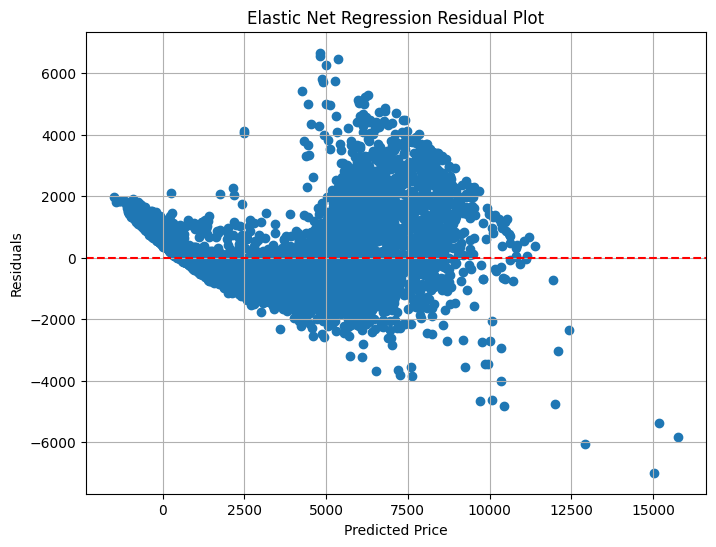

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(pred_elastic, y_test - pred_elastic)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Elastic Net Regression Residual Plot")
plt.grid(True)
plt.show()

comparison grpah of all models


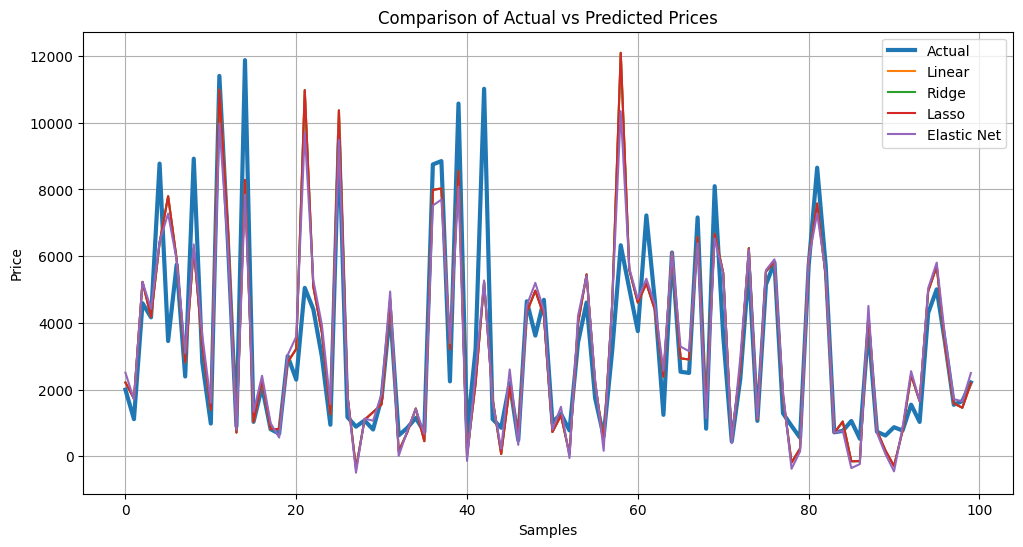

In [55]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual", linewidth=3)
plt.plot(pred_lr[:100], label="Linear")
plt.plot(pred_ridge[:100], label="Ridge")
plt.plot(pred_lasso[:100], label="Lasso")
plt.plot(pred_elastic[:100], label="Elastic Net")

plt.title("Comparison of Actual vs Predicted Prices")
plt.xlabel("Samples")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [57]:
# New diamond details
new_diamond = pd.DataFrame({
    'carat': [1.20],
    'cut': ['Premium'],
    'color': ['G'],
    'clarity': ['VS2'],
    'depth': [61.8],
    'table': [57],
    'x': [6.82],
    'y': [6.79],
    'z': [4.20]
})

# Encode categorical features
new_diamond['cut'] = cut_encoder.transform(new_diamond['cut'])
new_diamond['color'] = color_encoder.transform(new_diamond['color'])
new_diamond['clarity'] = clarity_encoder.transform(new_diamond['clarity'])

# Scale features
new_diamond_scaled = scaler.transform(new_diamond)

# Predict using the best model (change 'lr' if another model performed better)
predicted_price = lr.predict(new_diamond_scaled)

print("Predicted Diamond Price:", round(predicted_price[0], 2))

Predicted Diamond Price: 6803.6


In [56]:
import joblib

# Save all trained models
joblib.dump(lr, "linear_regression.pkl")
joblib.dump(ridge, "ridge_regression.pkl")
joblib.dump(lasso, "lasso_regression.pkl")
joblib.dump(elastic, "elastic_net_regression.pkl")

print("All models saved successfully!")

All models saved successfully!
